<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/BILAL_Assignment_15_Drop_Box_and_Instructions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install Required Libraries
!pip install boto3 sagemaker matplotlib pandas numpy --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.1/137.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.7/251.7 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 91.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import boto3
import zipfile
import os

In [20]:
# Download Household Power Consumption dataset
!wget -O household_power.zip https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip

--2026-03-13 22:28:07--  https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘household_power.zip’

household_power.zip     [     <=>            ]  19.68M  22.5MB/s    in 0.9s    

2026-03-13 22:28:09 (22.5 MB/s) - ‘household_power.zip’ saved [20640916]



In [21]:
with zipfile.ZipFile("household_power.zip", 'r') as zip_ref:
    zip_ref.extractall()

# Confirm file exists
os.listdir()

['.config',
 'household_power_consumption.txt',
 'household_power.zip',
 'individual+household+electric+power+consumption.zip',
 'sample_data']

In [22]:
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=";",
    low_memory=False
)
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [27]:
# Combine Date and Time into datetime
df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"], format="%d/%m/%Y %H:%M:%S", errors="coerce")
df = df.set_index("Datetime")

# Replace '?' with NaN
df.replace("?", np.nan, inplace=True)

# Convert numeric columns to float
numeric_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

for col in numeric_cols:
    df[col] = df[col].astype(float)

# Drop missing values
df = df.dropna()

print("Dataset shape after cleaning:", df.shape)
df.head()

Dataset shape after cleaning: (2049280, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [29]:
# Replace these with AWS IAM credentials
aws_access_key_id = "YOUR_ACCESS_KEY_ID"
aws_secret_access_key = "YOUR_SECRET_ACCESS_KEY"
aws_region = "us-east-1"  # change if your region is different

# Create CloudWatch and S3 clients
cloudwatch = boto3.client(
    "cloudwatch",
    aws_access_key_id=aws_access_key_id,
    aws_secret_access_key=aws_secret_access_key,
    region_name=aws_region
)

s3 = boto3.client(
    "s3",
    aws_access_key_id=aws_access_key_id,
    aws_secret_access_key=aws_secret_access_key,
    region_name=aws_region
)

# Test CloudWatch connection
try:
    response = cloudwatch.list_metrics()
    print("AWS CloudWatch connection successful")
    print("Region:", aws_region)
    print("Number of metrics retrieved:", len(response['Metrics']))
except Exception as e:
    print("Error connecting to CloudWatch:", e)

Error connecting to CloudWatch: An error occurred (InvalidClientTokenId) when calling the ListMetrics operation: The security token included in the request is invalid.


In [30]:
# Resample Global_active_power to weekly frequency
weekly_data = df["Global_active_power"].resample("W").mean()
weekly_data.head()

,Global_active_power
Datetime,
2006-12-17,2.505248
2006-12-24,1.734186
2006-12-31,1.958376
2007-01-07,1.484233
2007-01-14,1.604954


In [31]:
first_20_weeks = df["Global_active_power"].resample("W").agg(["mean","std","max"]).head(20)
first_20_weeks

,mean,std,max
Datetime,,,
2006-12-17,2.505248,1.204002,7.706
2006-12-24,1.734186,1.435826,8.698
2006-12-31,1.958376,1.401733,9.132
2007-01-07,1.484233,1.189513,8.044
2007-01-14,1.604954,1.400330,9.272
2007-01-21,1.639451,1.391636,8.658
2007-01-28,1.517470,1.218572,7.722
2007-02-04,1.703608,1.326943,7.904
2007-02-11,1.494935,1.252151,7.426


In [32]:
namespace = "WeeklyPowerForecast"

for index, row in first_20_weeks.iterrows():
    cloudwatch.put_metric_data(
        Namespace=namespace,
        MetricData=[
            {"MetricName": "weekly_avg_power", "Value": float(row["mean"]), "Unit": "None"},
            {"MetricName": "weekly_std_power", "Value": float(row["std"]), "Unit": "None"},
            {"MetricName": "weekly_max_power", "Value": float(row["max"]), "Unit": "None"}
        ]
    )

print("Metrics successfully logged to CloudWatch.")

ClientError: An error occurred (InvalidClientTokenId) when calling the PutMetricData operation: The security token included in the request is invalid.

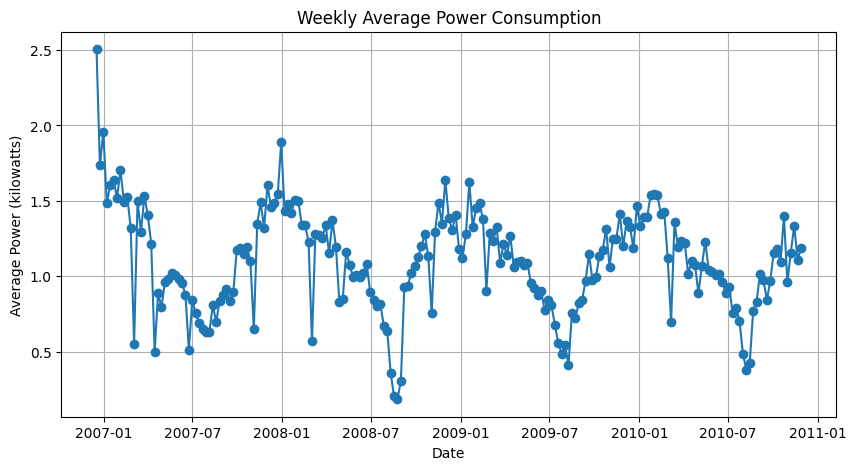

In [33]:
plt.figure(figsize=(10,5))
plt.plot(weekly_data, marker='o')
plt.title("Weekly Average Power Consumption")
plt.xlabel("Date")
plt.ylabel("Average Power (kilowatts)")
plt.grid(True)
plt.show()

Plot saved as: weekly_avg_plot.png


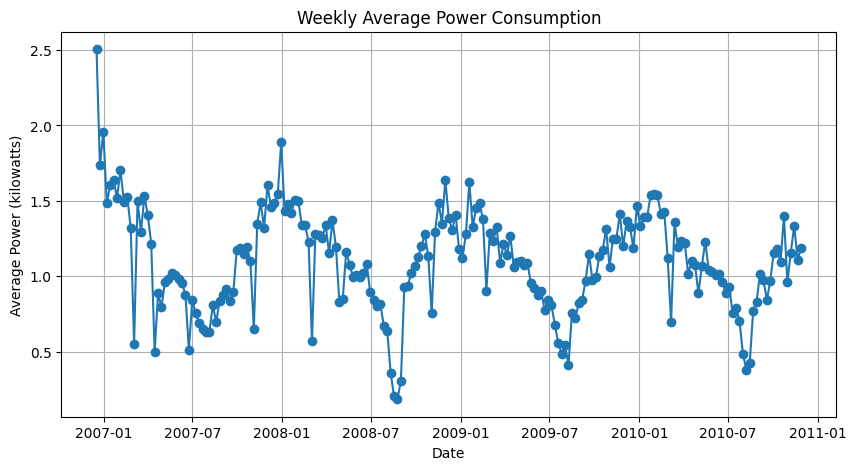

In [34]:
image_file = "weekly_avg_plot.png"
plt.figure(figsize=(10,5))
plt.plot(weekly_data, marker='o')
plt.title("Weekly Average Power Consumption")
plt.xlabel("Date")
plt.ylabel("Average Power (kilowatts)")
plt.grid(True)
plt.savefig(image_file)
print("Plot saved as:", image_file)

In [35]:
# Replace with your S3 bucket
bucket_name = "your-bucket-name"  # <-- create one if you don't have

s3.upload_file(image_file, bucket_name, "weekly_avg_plot.png")
print(f"Plot uploaded to S3: s3://{bucket_name}/weekly_avg_plot.png")

S3UploadFailedError: Failed to upload weekly_avg_plot.png to your-bucket-name/weekly_avg_plot.png: An error occurred (InvalidAccessKeyId) when calling the PutObject operation: The AWS Access Key Id you provided does not exist in our records.

In [36]:
# List S3 objects in the bucket folder
response = s3.list_objects_v2(Bucket=bucket_name)
for obj in response.get('Contents', []):
    print("S3 Object:", obj['Key'])

ClientError: An error occurred (InvalidAccessKeyId) when calling the ListObjectsV2 operation: The AWS Access Key Id you provided does not exist in our records.